# Esercizio 3.1 - CartPole e LunarLander con A2C

Questo notebook contiene il flusso A2C finale. Training, valutazione, selezione dei modelli, grafici e visualizzazione sono importati dal package `dla_lab3`.

Il percorso valida A2C su `CartPole-v1`, confronta preset e checkpoint LunarLander, seleziona congiuntamente checkpoint, modalità delle azioni e temperatura, quindi esegue la valutazione finale e cinque rollout qualitativi.


> **Ambiente di esecuzione**
>
> Il laboratorio è stato eseguito in Ubuntu/WSL con il kernel `Python (DRL)`. Installare dalla root della repository con `python -m pip install -r requirements.txt`.
>
> Gli output della run completa sono preservati. Nella consegna training, selezioni estese, rivalutazione finale e rendering sono disattivati; CSV, JSON e figure versionati vengono caricati in sola lettura.


## Riferimenti e motivazione degli iperparametri

`LunarLander-v3` ha osservazioni di forma `(8,)`, azioni `Discrete(4)`, reward shaping e soglia convenzionale di soluzione pari a 200 punti medi. A2C usa ambienti vettorizzati; la configurazione riprende come punto di partenza i valori documentati da Stable-Baselines3 e RL Baselines3 Zoo, poi valutati nelle run locali.

Fonti: [Gymnasium LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/), [Stable-Baselines3 A2C](https://stable-baselines3.readthedocs.io/en/master/modules/a2c.html), [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo/blob/master/hyperparams/a2c.yml).


## 1. Configurazione

I preset sono letti da `config/lab3_defaults.yaml`. La cella importa funzioni e classi, risolve percorsi relativi alla root del laboratorio e imposta il seed. L'output atteso identifica configurazione e seed senza installare pacchetti o modificare checkpoint.


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


from dla_lab3 import (
    A2CConfig,
    a2c_from_env,
    collect_current_lunar_candidates,
    evaluate_a2c_policy,
    evaluate_lunar_candidates,
    evaluate_lunar_policy_configurations,
    final_lunar_evaluation,
    load_a2c_checkpoint,
    load_lab_config,
    make_env,
    observation_scale,
    plot_lunar_selection,
    plot_temperature_sweep,
    print_lunar_preset_summary,
    print_training_scope,
    run_lunar_visual_episodes,
    select_lunar_checkpoint,
    select_lunar_policy_configuration,
    set_seed,
    train_a2c_single_env,
    train_lunar_presets,
)
from dla_lab3.paths import checkpoint_dir
from IPython.display import Image, SVG, display

CONFIG_PATH = PROJECT_ROOT / "config" / "lab3_defaults.yaml"
LAB_CONFIG = load_lab_config(CONFIG_PATH)

SEED = int(LAB_CONFIG["seed"])
LL_CONFIG = LAB_CONFIG["a2c_lunarlander"]
set_seed(SEED)

print(f"Radice del progetto: {PROJECT_ROOT.name}")
print(f"Configurazione: {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"Seed: {SEED}")
LOAD_SAVED_RESULTS = True
DISPLAY_SAVED_RESULTS = True
USE_VERSIONED_METRICS = True


Project root: ./DLA_3
Config file:  DLA_3/config/lab3_defaults.yaml
Seed:         2112


## 2. Controllo degli ambienti

La cella verifica spazi di osservazione e azione e una transizione campione per CartPole e LunarLander. Non esegue training e chiude entrambi gli ambienti.


In [3]:
for env_id, kwargs in [
    ("CartPole-v1", {}),
    ("LunarLander-v3", {"continuous": False, "enable_wind": False}),
]:
    env = make_env(env_id, seed=SEED, **kwargs)
    obs, _ = env.reset(seed=SEED)
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)

    print("\n" + "=" * 72)
    print(env_id)
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)
    print("Initial observation:", np.round(obs, 4))
    print("Sample action:", action)
    print("Next observation:", np.round(next_obs, 4))
    print("Reward:", round(float(reward), 4))
    print("Terminated:", terminated, "| Truncated:", truncated)
    env.close()



CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [-0.0416  0.0333 -0.0422  0.0172]
Sample action: 0
Next observation: [-0.0409 -0.1612 -0.0418  0.2963]
Reward: 1.0
Terminated: False | Truncated: False

LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Initial observation: [-0.0032  1.4177 -0.3276  0.3024  0.0038  0.0742  0.      0.    ]
Sample action: 1
Next observation: [-0.0065  1.4239 -0.3346  0.2761  0.0089  0.1034  0.      0.    ]
Reward: 0.0256
Terminated: False | Truncated: False


## 3. Controllo A2C su CartPole

CartPole verifica che l'implementazione A2C risolva un compito di controllo più semplice. La run completa ha ottenuto return greedy medio `494.51` con deviazione standard `19.68`. Nella consegna training e rivalutazione a 100 episodi sono disattivati; la metrica viene caricata da `results/method_summary.csv`.


In [4]:
RUN_CARTPOLE_TRAINING = False
RUN_CARTPOLE_EVALUATION = False
cartpole_ckpt = checkpoint_dir("a2c_cartpole_gae.pt", create=RUN_CARTPOLE_TRAINING)

train_env = make_env("CartPole-v1", seed=SEED)
eval_env = make_env("CartPole-v1", seed=SEED + 1000)
obs_scale_cp = observation_scale("CartPole-v1")
net_cp = a2c_from_env(train_env, hidden_size=128)

if RUN_CARTPOLE_TRAINING:
    config_cp = A2CConfig(
        gamma=0.99,
        lr=3e-4,
        value_coef=0.5,
        entropy_coef=0.01,
        entropy_coef_min=0.001,
        num_episodes=800,
        max_episode_steps=500,
        eval_every=25,
        eval_episodes=20,
        gae_lambda=0.95,
        normalize_advantage=True,
        grad_clip=0.5,
        solved_threshold=475.0,
        checkpoint_path=str(cartpole_ckpt),
        stop_when_solved=True,
    )
    history_cp = train_a2c_single_env(net_cp, train_env, eval_env, obs_scale_cp, config_cp)
    print("CartPole training solved:", history_cp["solved"])
    print("Best evaluation return:", round(history_cp["best_eval_return"], 2))
else:
    print("CartPole training skipped; using existing checkpoint if available:", cartpole_ckpt)

if RUN_CARTPOLE_EVALUATION and cartpole_ckpt.exists():
    load_a2c_checkpoint(net_cp, cartpole_ckpt)
    cartpole_metrics = evaluate_a2c_policy(
        eval_env,
        net_cp,
        obs_scale_cp,
        n_eval=100,
        mode="greedy",
        seed_start=40_000,
        max_episode_steps=500,
    )
else:
    cartpole_metrics = None
    saved_cartpole = pd.read_csv(PROJECT_ROOT / "results" / "method_summary.csv").query(
        "environment == 'CartPole-v1' and method == 'A2C'"
    )
    print("Valutazione CartPole non rieseguita: viene mostrata la metrica versionata.")
    if DISPLAY_SAVED_RESULTS:
        display(saved_cartpole)

train_env.close()
eval_env.close()

if cartpole_metrics is not None:
    print("CARTPOLE GREEDY EVALUATION")
    print("Return medio:", round(cartpole_metrics["avg_return"], 2))
    print("Std return:", round(cartpole_metrics["std_return"], 2))
    print("Lunghezza media:", round(cartpole_metrics["avg_length"], 2))


CartPole training solved: True
Best evaluation return: 491.7
CARTPOLE GREEDY EVALUATION
Average return: 494.51
Std return: 19.68
Average length: 494.51


## 4. Piano sperimentale LunarLander

I preset selezionati provengono dalla configurazione YAML. I checkpoint prodotti dal flusso corrente costituiscono i candidati per la selezione; le prove esplorative storiche restano documentazione e non vengono incluse automaticamente.


In [5]:
SELECTED_LUNAR_EXPERIMENTS = list(LL_CONFIG["default_experiments"])
RUN_LUNAR_EXPERIMENTS = False

print_lunar_preset_summary(LL_CONFIG, SELECTED_LUNAR_EXPERIMENTS)
print()
print_training_scope(LL_CONFIG, SELECTED_LUNAR_EXPERIMENTS)
print()
print("RUN_LUNAR_EXPERIMENTS:", RUN_LUNAR_EXPERIMENTS)


Reference note:
RL Zoo tuned A2C for LunarLander-v3 uses n_envs=8, n_timesteps=2e5, gamma=0.995, n_steps=5, learning_rate=0.00083 and ent_coef=0.00001.

Available presets:
  sb3_zoo_short: Fast run inspired by RL Zoo tuned A2C hyperparameters. | timesteps=100000 | n_envs=8 | lr=0.00083 | reward_scale=100.0
  sb3_zoo_full: RL Zoo reference budget adapted to this local A2C implementation. | timesteps=200000 | n_envs=8 | lr=0.00083 | reward_scale=100.0
* sb3_zoo_raw_current: Current RL-Zoo-style A2C run without extra reward scaling; used as a clean reproducible baseline. | timesteps=300000 | n_envs=8 | lr=0.00083 -> 0.0 | reward_scale=1.0
  separate_short: Fast version of the old separate actor-critic run. | timesteps=100000 | n_envs=8 | lr=0.00083 | reward_scale=1.0
  separate_full_old: Full old separate actor-critic run from Lab3_A2C. | timesteps=1000000 | n_envs=16 | lr=0.00083 | reward_scale=1.0
* separate_current_long: Full reproducible separate actor-critic run generated inside LAB_

## 5. Training dei preset LunarLander

Quando attivata, la cella salva per ogni preset i checkpoint `best_eval`, `best_train` e `last`. Il budget è stampato nella cella precedente. Nella consegna `RUN_LUNAR_EXPERIMENTS=False`, quindi nessun checkpoint viene creato o sovrascritto.


In [6]:
lunar_histories = train_lunar_presets(
    selected_experiments=SELECTED_LUNAR_EXPERIMENTS,
    ll_config=LL_CONFIG,
    seed=SEED,
    run_training=RUN_LUNAR_EXPERIMENTS,
)



SKIPPING COMPLETED PRESET: sb3_zoo_raw_current
Existing checkpoints found:
- DLA_3/checkpoints/a2c_lunarlander_sb3_zoo_raw_current.pt
- DLA_3/checkpoints/a2c_lunarlander_sb3_zoo_raw_current_best_train.pt
- DLA_3/checkpoints/a2c_lunarlander_sb3_zoo_raw_current_last.pt



SKIPPING COMPLETED PRESET: separate_current_long
Existing checkpoints found:
- DLA_3/checkpoints/a2c_lunarlander_separate_current_long.pt
- DLA_3/checkpoints/a2c_lunarlander_separate_current_long_best_train.pt
- DLA_3/checkpoints/a2c_lunarlander_separate_current_long_last.pt

SKIPPING COMPLETED PRESET: landing_refine_current_long
Existing checkpoints found:
- DLA_3/checkpoints/a2c_lunarlander_landing_refine_current_long.pt
- DLA_3/checkpoints/a2c_lunarlander_landing_refine_current_long_best_train.pt
- DLA_3/checkpoints/a2c_lunarlander_landing_refine_current_long_last.pt

SKIPPING COMPLETED PRESET: landing_maskfix_refine_current
Existing checkpoints found:
- DLA_3/checkpoints/a2c_lunarlander_landing_maskfix_refine_current.pt
- DLA_3/checkpoints/a2c_lunarlander_landing_maskfix_refine_current_best_train.pt
- DLA_3/checkpoints/a2c_lunarlander_landing_maskfix_refine_current_last.pt


## 6. Valutazione dei checkpoint correnti

La selezione usa episodi nuovi e ordina i candidati per return medio, success rate e deviazione standard. Con il flag disattivato, il checkpoint e le metriche selezionate vengono letti dal JSON finale versionato e la figura di confronto viene mostrata senza rivalutazione.

![Selezione checkpoint LunarLander](../figures/lunarlander_checkpoint_selection.png)


a2c_lunarlander_sb3_zoo_raw_current.pt: avg=156.19, std=105.18, success=52.0%
a2c_lunarlander_sb3_zoo_raw_current_best_train.pt: avg=118.91, std=126.91, success=40.0%
a2c_lunarlander_sb3_zoo_raw_current_last.pt: avg=16.64, std=102.75, success=14.0%
a2c_lunarlander_separate_current_long.pt: avg=-9.72, std=132.63, success=13.0%
a2c_lunarlander_separate_current_long_best_train.pt: avg=80.12, std=113.12, success=15.0%
a2c_lunarlander_separate_current_long_last.pt: avg=24.87, std=120.64, success=9.0%
a2c_lunarlander_landing_refine_current_long.pt: avg=-9.80, std=151.70, success=16.0%
a2c_lunarlander_landing_refine_current_long_best_train.pt: avg=21.30, std=171.01, success=29.0%
a2c_lunarlander_landing_refine_current_long_last.pt: avg=-5.22, std=147.55, success=17.0%
a2c_lunarlander_landing_maskfix_refine_current.pt: avg=-13.74, std=133.39, success=13.0%
a2c_lunarlander_landing_maskfix_refine_current_best_train.pt: avg=4.07, std=137.84, success=15.0%
a2c_lunarlander_landing_maskfix_refine_cu

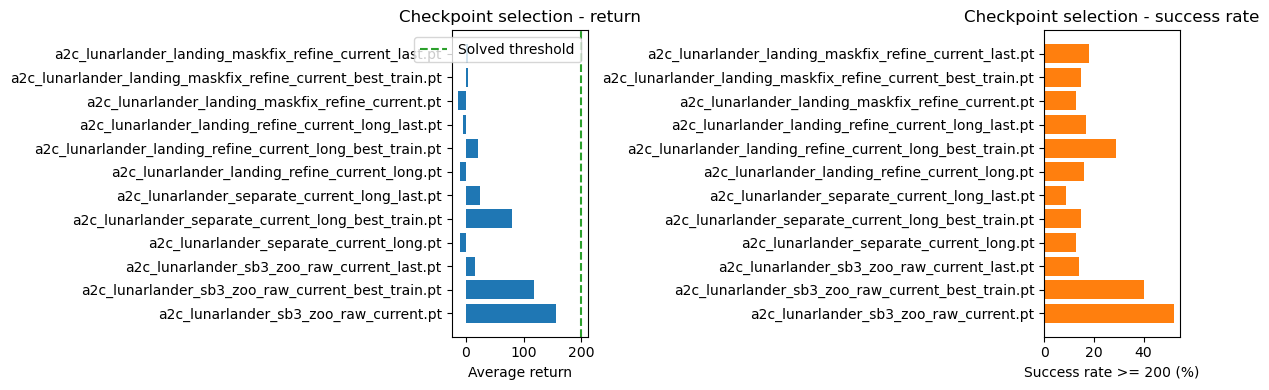

In [7]:
RUN_LUNAR_CHECKPOINT_SELECTION = False
FINAL_LUNAR_RESULTS = PROJECT_ROOT / "results" / "lunarlander_final_evaluation.json"

if RUN_LUNAR_CHECKPOINT_SELECTION:
    lunar_candidates = collect_current_lunar_candidates(
        selected_experiments=SELECTED_LUNAR_EXPERIMENTS,
        ll_config=LL_CONFIG,
        histories=lunar_histories,
    )
    selection_results = evaluate_lunar_candidates(lunar_candidates, LL_CONFIG)
    selected_checkpoint = select_lunar_checkpoint(
        selection_results,
        metric=str(LL_CONFIG["selection_metric"]),
    )
    plot_lunar_selection(selection_results, solved_threshold=float(LL_CONFIG["solved_threshold"]))
else:
    selection_results = []
    saved_final_metrics = json.loads(FINAL_LUNAR_RESULTS.read_text(encoding="utf-8"))
    selected_checkpoint = {
        "name": saved_final_metrics["checkpoint"],
        "path": str(checkpoint_dir(saved_final_metrics["checkpoint"], create=False)),
        "preset": saved_final_metrics["preset"],
        "source": "versioned final evaluation",
    }
    print("Selezione checkpoint non rieseguita: configurazione caricata da", FINAL_LUNAR_RESULTS.relative_to(PROJECT_ROOT))
    if DISPLAY_SAVED_RESULTS:
        display(Image(filename=PROJECT_ROOT / "figures" / "lunarlander_checkpoint_selection.png"))


## 7. Selezione della configurazione finale della policy

Una configurazione comprende checkpoint, modalità greedy/campionata e temperatura. La selezione congiunta evita di scegliere la temperatura soltanto dopo il checkpoint. Nella consegna vengono caricati modalità `sample` e temperatura `0.75` già verificate.

![Sweep della temperatura](../figures/lunarlander_temperature_sweep.svg)

![Modalità della policy](../figures/lunarlander_policy_mode_comparison.svg)

L'output esteso incorporato nella cella successiva documenta lo sweep precedente che aveva selezionato `T=0.85`. È conservato come evidenza del processo; la configurazione finale canonica è `T=0.75`, letta dai risultati versionati.


Policy-configuration evaluation setup:
- first pass evaluated 12 checkpoints with mode=sample and T=1.00
- second pass evaluates 6 checkpoint candidates
- for each candidate: greedy + sample temperatures [0.25, 0.35, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.95, 1.1, 1.25]
- episodes per configuration: 100
Checkpoint candidates:
  - a2c_lunarlander_sb3_zoo_raw_current.pt (sb3_zoo_raw_current): top 4 by average return at T=1.0; top 4 by success rate at T=1.0
  - a2c_lunarlander_sb3_zoo_raw_current_best_train.pt (sb3_zoo_raw_current): top 4 by average return at T=1.0; top 4 by success rate at T=1.0
  - a2c_lunarlander_separate_current_long_best_train.pt (separate_current_long): top 4 by average return at T=1.0
  - a2c_lunarlander_separate_current_long_last.pt (separate_current_long): top 4 by average return at T=1.0
  - a2c_lunarlander_landing_refine_current_long_best_train.pt (landing_refine_current_long): top 4 by success rate at T=1.0
  - a2c_lunarlander_landing_maskfix_refine_cu

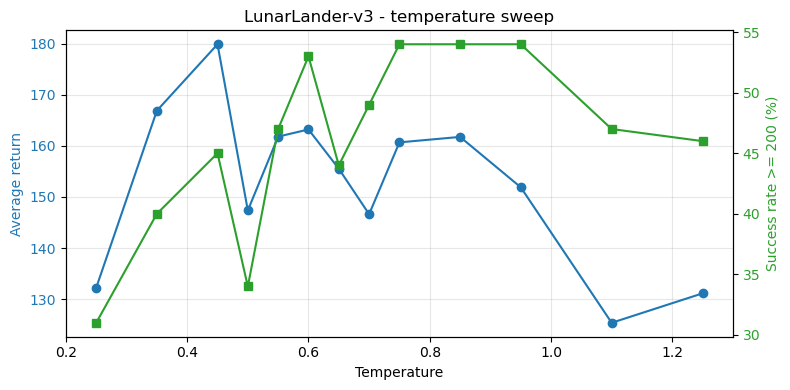

In [8]:
RUN_LUNAR_POLICY_SELECTION = False

if RUN_LUNAR_POLICY_SELECTION:
    policy_results = evaluate_lunar_policy_configurations(selection_results, LL_CONFIG)
    selected_policy = select_lunar_policy_configuration(
        policy_results,
        metric=str(LL_CONFIG["policy_selection_metric"]),
    )
    plot_temperature_sweep([
        row for row in policy_results
        if row["mode"] == "sample" and row["path"] == selected_policy["path"]
    ])
else:
    policy_results = []
    selected_policy = {
        **selected_checkpoint,
        "mode": saved_final_metrics["mode"],
        "temperature": float(saved_final_metrics["temperature"]),
    }
    if DISPLAY_SAVED_RESULTS:
        display(SVG(filename=PROJECT_ROOT / "figures" / "lunarlander_temperature_sweep.svg"))
        display(SVG(filename=PROJECT_ROOT / "figures" / "lunarlander_policy_mode_comparison.svg"))
    print(
        "Selezione policy non rieseguita; modalità caricata="
        f"{selected_policy['mode']} T={selected_policy['temperature']:.2f}."
    )


## 8. Valutazione finale

La valutazione completa usa 200 episodi con seed distinti. Con `RUN_FULL_LUNAR_EVALUATION=False` il notebook legge il JSON finale e mostra return medio, deviazione standard, success rate, lunghezza, terminazioni e frequenze delle azioni senza modificare file.

![Valutazione finale LunarLander](../figures/lunarlander_final_evaluation.svg)

![Frequenze delle azioni](../figures/lunarlander_action_frequencies.svg)

L'output testuale incorporato (`166.88 ± 101.92`, successo `61%`, `T=0.85`) appartiene alla valutazione precedente ed è mantenuto per provenienza. I valori finali correnti sono `165.76 ± 100.56` e successo `56%` a `T=0.75`; il percorso rapido li carica dal JSON versionato.


In [9]:
RUN_FULL_LUNAR_EVALUATION = False

if RUN_FULL_LUNAR_EVALUATION:
    final_metrics = final_lunar_evaluation(
        selected_checkpoint=selected_policy,
        ll_config=LL_CONFIG,
        temperature=float(selected_policy["temperature"]),
        mode=str(selected_policy["mode"]),
    )
else:
    final_metrics = json.loads(FINAL_LUNAR_RESULTS.read_text(encoding="utf-8"))
    print("Valutazione finale non rieseguita: metriche su 200 episodi caricate da", FINAL_LUNAR_RESULTS.relative_to(PROJECT_ROOT))
    if DISPLAY_SAVED_RESULTS:
        display(SVG(filename=PROJECT_ROOT / "figures" / "lunarlander_final_evaluation.svg"))
        display(SVG(filename=PROJECT_ROOT / "figures" / "lunarlander_action_frequencies.svg"))
    print(
        f"Return medio={final_metrics['average_return']:.2f}, "
        f"std={final_metrics['standard_deviation_return']:.2f}, "
        f"success={final_metrics['success_rate_percent']:.1f}%"
    )


FINAL LUNARLANDER EVALUATION
Checkpoint: a2c_lunarlander_sb3_zoo_raw_current.pt
Source: current_folder
Preset: sb3_zoo_raw_current
Temperature: 0.85
Average return: 166.88
Std return: 101.92
Min return: -130.53
Max return: 302.93
Average length: 455.92
Success rate >= 200: 61.0%
Terminated episodes: 199/200
Truncated episodes: 1/200
Action frequencies: [0.182, 0.169, 0.48, 0.168]
Last-quarter action frequencies: [0.55, 0.102, 0.251, 0.097]
Final |x|: 0.122
Final |vertical velocity|: 0.016
Final |angle|: 0.087
Final leg contact rates: 84.5% / 90.5%


## 9. Valutazione visuale: cinque episodi LunarLander

I rollout usano la configurazione selezionata, ma il rendering è disattivato. Il riepilogo JSON conserva seed, return, lunghezza, `terminated`, `truncated`, successo e frequenze delle azioni; i frame e gli HTML delle animazioni non sono incorporati.

Il JSON visuale versionato documenta un controllo qualitativo precedente a `T=0.85`; resta distinto dalla selezione finale a `T=0.75` e non contribuisce alle metriche aggregate su 200 episodi.


In [10]:
RUN_LUNAR_VISUALIZATION = False
LUNAR_VISUAL_RESULTS = PROJECT_ROOT / "results" / "lunarlander_visual_episodes.json"

if RUN_LUNAR_VISUALIZATION:
    visual_rollouts = run_lunar_visual_episodes(
        checkpoint_path=selected_policy["path"],
        temperature=float(selected_policy["temperature"]),
        mode=str(selected_policy["mode"]),
        n_episodes=int(LL_CONFIG["visual_episodes"]),
        seed_start=100_000,
        show_inline=True,
        summary_path=LUNAR_VISUAL_RESULTS,
    )
else:
    print("Rendering LunarLander disattivato; viene mostrato il riepilogo salvato.")
    if LUNAR_VISUAL_RESULTS.is_file():
        visual_rollouts = json.loads(LUNAR_VISUAL_RESULTS.read_text(encoding="utf-8"))
        print(
            "Configurazione visuale salvata: "
            f"modalità={visual_rollouts['mode']} "
            f"T={float(visual_rollouts['temperature']):.2f}."
        )
        for row in visual_rollouts["episodes"]:
            print(
                f"episode={row['episode']} seed={row['seed']} return={row['return']:.2f} "
                f"length={row['length']} terminated={row['terminated']} "
                f"truncated={row['truncated']} success={row['success']}"
            )
    else:
        visual_rollouts = None
        print("Riepilogo non disponibile; attivare il flag con il checkpoint locale.")


episode=1 seed=100000 return=234.61 length=434 terminated=True truncated=False success=True

Visual episode 1/5


episode=2 seed=100001 return=189.29 length=497 terminated=True truncated=False success=False

Visual episode 2/5


episode=3 seed=100002 return=7.06 length=429 terminated=True truncated=False success=False

Visual episode 3/5


episode=4 seed=100003 return=201.54 length=519 terminated=True truncated=False success=True

Visual episode 4/5


episode=5 seed=100004 return=174.26 length=455 terminated=True truncated=False success=False

Visual episode 5/5


## Discussione e limiti

La policy selezionata è il checkpoint A2C in stile RL Zoo con campionamento a `T=0.75`. Su 200 episodi ottiene return medio `165.76`, deviazione standard `100.56`, success rate `56.0%` e troncamento `2.0%`.

Il risultato migliora le varianti di raffinamento non riuscite, ma non supera la soglia media di 200 e presenta elevata variabilità. La conclusione corretta è quindi che la policy atterra con successo in molti episodi, non che LunarLander sia risolto stabilmente. Selezione di checkpoint, modalità e temperatura resta essenziale.


## Dichiarazione sull'uso dell'IA e delle risorse

ChatGPT/Codex ha supportato riorganizzazione, documentazione e controlli. Gli iperparametri sono stati confrontati con le fonti indicate; esecuzione, risultati e interpretazione finale restano responsabilità dell'autore.


## Funzioni, classi e moduli locali richiamati

La tabella è ricavata dagli import, dagli utilizzi nelle celle e dalle definizioni effettive nei package locali.

| Funzione o classe | Tipo | File di definizione | Scopo | Input principali | Output principali | Sezione |
| ----------------- | ---- | ------------------- | ----- | ---------------- | ----------------- | ------- |
| `a2c_from_env` | Funzione | `src/dla_lab3/a2c.py` | Costruisce una rete A2C condivisa da un ambiente Gymnasium. | `env`, `hidden_size: int` | Istanza di `A2CNet`. | 3. Controllo A2C su CartPole |
| `A2CConfig` | Classe | `src/dla_lab3/a2c.py` | Configurazione di training per gli esperimenti Advantage Actor-Critic. | `gamma`, `lr`, `value_coef`, `entropy_coef`, `entropy_coef_min`, `num_episodes`, `max_episode_steps`, `eval_every` | Istanza configurata della classe. | 3. Controllo A2C su CartPole |
| `checkpoint_dir` | Funzione | `src/dla_lab3/paths.py` | Restituisce un percorso interno a `checkpoints`. | `create: bool`, `*parts` | Percorso interno alla cartella `checkpoints`. | 3. Controllo A2C su CartPole; 6. Valutazione dei checkpoint correnti |
| `collect_current_lunar_candidates` | Funzione | `src/dla_lab3/experiments.py` | Raccoglie i checkpoint candidati generati dal flusso corrente. | `selected_experiments: list[str]`, `ll_config: dict[str, Any]`, `histories: dict[str, dict[str, Any]] \| None` | Lista di candidati con nome, fonte, preset e percorso. | 6. Valutazione dei checkpoint correnti |
| `evaluate_a2c_policy` | Funzione | `src/dla_lab3/a2c.py` | Valuta una policy A2C su più episodi. | `env`, `net: nn.Module`, `obs_scale: torch.Tensor`, `n_eval: int`, `mode: ActionMode`, `temperature: float`, `seed_start: int`, `max_episode_steps: int` | Dizionario con return medio, lunghezza media e metriche di dispersione, success rate, conteggi terminali e frequenze delle azioni. | 3. Controllo A2C su CartPole |
| `evaluate_lunar_candidates` | Funzione | `src/dla_lab3/experiments.py` | Valuta tutti i checkpoint LunarLander candidati. | `candidates: list[dict[str, Any]]`, `ll_config: dict[str, Any]` | Lista dei dizionari dei risultati di valutazione. | 6. Valutazione dei checkpoint correnti |
| `evaluate_lunar_policy_configurations` | Funzione | `src/dla_lab3/experiments.py` | Valuta combinazioni di checkpoint, modalità delle azioni e temperatura. | `selection_results: list[dict[str, Any]]`, `ll_config: dict[str, Any]` | Lista dei dizionari di valutazione delle configurazioni della policy. | 7. Selezione della configurazione finale della policy |
| `final_lunar_evaluation` | Funzione | `src/dla_lab3/experiments.py` | Esegue la valutazione finale LunarLander. | `selected_checkpoint: dict[str, Any]`, `ll_config: dict[str, Any]`, `temperature: float`, `mode: str` | Metriche della valutazione finale. | 8. Valutazione finale |
| `load_a2c_checkpoint` | Funzione | `src/dla_lab3/a2c.py` | Carica un checkpoint A2C in una rete. | `net: nn.Module`, `checkpoint_path: str \| Path` | La rete in input caricata con i pesi e impostata in modalità eval. | 3. Controllo A2C su CartPole |
| `load_lab_config` | Funzione | `src/dla_lab3/config.py` | Carica il file di configurazione del laboratorio. | `path: str \| Path` | Dizionario con la configurazione del laboratorio. | 1. Configurazione |
| `make_env` | Funzione | `src/dla_lab3/envs.py` | Crea un ambiente Gymnasium e ne imposta il seed. | `env_id: str`, `seed: int \| None`, `render_mode: str \| None`, `**kwargs` | Ambiente Gymnasium pronto per l'uso. | 2. Controllo degli ambienti; 3. Controllo A2C su CartPole |
| `observation_scale` | Funzione | `src/dla_lab3/envs.py` | Restituisce la scala delle osservazioni per gli ambienti supportati. | `env_id: str` | Tensore float con un valore per dimensione dell'osservazione. | 3. Controllo A2C su CartPole |
| `plot_lunar_selection` | Funzione | `src/dla_lab3/experiments.py` | Traccia le metriche di selezione dei checkpoint. | `selection_results: list[dict[str, Any]]`, `solved_threshold: float` | Figura Matplotlib mostrata nel notebook. | 6. Valutazione dei checkpoint correnti |
| `plot_temperature_sweep` | Funzione | `src/dla_lab3/experiments.py` | Traccia i risultati dello sweep della temperatura. | `temperature_results: list[dict[str, Any]]` | Figura Matplotlib mostrata nel notebook. | 7. Selezione della configurazione finale della policy |
| `print_lunar_preset_summary` | Funzione | `src/dla_lab3/experiments.py` | Stampa la tabella dei preset LunarLander in forma leggibile. | `ll_config: dict[str, Any]`, `selected_experiments: list[str]` | Nessuno; stampa un riepilogo conciso. | 4. Piano sperimentale LunarLander |
| `print_training_scope` | Funzione | `src/dla_lab3/experiments.py` | Stampa il budget di training di ogni preset selezionato. | `ll_config: dict[str, Any]`, `selected_experiments: list[str]` | Nessuno; stampa un riepilogo tabellare. | 4. Piano sperimentale LunarLander |
| `run_lunar_visual_episodes` | Funzione | `src/dla_lab3/visualization.py` | Esegue e mostra episodi LunarLander senza includere frame nel JSON. | `checkpoint_path: str \| Path`, `temperature: float`, `mode: str`, `n_episodes: int`, `seed_start: int`, `show_inline: bool`, `summary_path: str \| Path \| None` | Dizionario con configurazione, seed, return e lunghezze degli episodi. I frame non sono inclusi nel valore restituito o nell'eventuale JSON. | 9. Valutazione visuale: cinque episodi LunarLander |
| `select_lunar_checkpoint` | Funzione | `src/dla_lab3/experiments.py` | Seleziona il checkpoint migliore dai risultati di valutazione correnti. | `selection_results: list[dict[str, Any]]`, `metric: str` | Dizionario del risultato selezionato. | 6. Valutazione dei checkpoint correnti |
| `select_lunar_policy_configuration` | Funzione | `src/dla_lab3/experiments.py` | Seleziona checkpoint, modalità delle azioni e temperatura finali. | `policy_results: list[dict[str, Any]]`, `metric: str` | Dizionario della configurazione selezionata. | 7. Selezione della configurazione finale della policy |
| `set_seed` | Funzione | `src/dla_lab3/seed.py` | Imposta i seed di Python, NumPy e PyTorch. | `seed: int` | Nessuno. Modifica lo stato globale dei generatori casuali e, se disponibile, quello di tutti i device CUDA. | 1. Configurazione |
| `train_a2c_single_env` | Funzione | `src/dla_lab3/a2c.py` | Addestra A2C su un singolo ambiente. | `net: nn.Module`, `train_env`, `eval_env`, `obs_scale: torch.Tensor`, `config: A2CConfig` | Dizionario storico con return di training, loss, metriche di valutazione e percorso del checkpoint migliore. | 3. Controllo A2C su CartPole |
| `train_lunar_presets` | Funzione | `src/dla_lab3/experiments.py` | Addestra i preset A2C LunarLander selezionati. | `selected_experiments: list[str]`, `ll_config: dict[str, Any]`, `seed: int`, `run_training: bool` | Dizionario che associa i preset alle cronologie di training. | 5. Training dei preset LunarLander |
